# Probability Distribution

    This is one of the most important topics in statistics and data science because it forms the basis for normal distributions, hypothesis testing, machine learning, and predictive analytics.

    Probability Distribution is one of the most fundamental concepts in Statistics, Data Science, Machine Learning, Artificial Intelligence, and Business Analytics.

    It describes how the probabilities of different possible outcomes of a random variable are distributed.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [4]:
np.random.seed(42)

Retail = pd.DataFrame({

    "Transaction_ID": range(10001,10401),

    "Customer_Age": np.random.randint(18,65,400),

    "Product_Category": np.random.choice(
        ["Electronics","Clothing","Grocery","Furniture"],
        400,
        p=[0.30,0.25,0.30,0.15]
    ),

    "Units_Purchased": np.random.choice(
        [1,2,3,4,5],
        400,
        p=[0.20,0.35,0.25,0.15,0.05]
    ),

    "Total_Bill": np.random.randint(
        500,
        15000,
        400
    ),

    "Payment_Mode": np.random.choice(
        ["Cash","UPI","Card"],
        400,
        p=[0.20,0.45,0.35]
    ),

    "Customer_Type": np.random.choice(
        ["New","Existing"],
        400,
        p=[0.30,0.70]
    ),

    "Discount_Applied": np.random.choice(
        ["Yes","No"],
        400,
        p=[0.35,0.65]
    )

})

Retail.head()

,Transaction_ID,Customer_Age,Product_Category,Units_Purchased,Total_Bill,Payment_Mode,Customer_Type,Discount_Applied
0,10001,56,Grocery,3,12107,UPI,Existing,Yes
1,10002,46,Clothing,2,8702,Card,Existing,No
2,10003,32,Electronics,2,13873,UPI,New,No
3,10004,60,Furniture,4,2368,UPI,Existing,Yes
4,10005,25,Grocery,2,8378,UPI,New,No


In [5]:
Retail.shape


(400, 8)

In [6]:
Retail.columns

Index(['Transaction_ID', 'Customer_Age', 'Product_Category', 'Units_Purchased',
       'Total_Bill', 'Payment_Mode', 'Customer_Type', 'Discount_Applied'],
      dtype='object')

In [7]:
Retail.dtypes

Transaction_ID       int64
Customer_Age         int32
Product_Category    object
Units_Purchased      int64
Total_Bill           int32
Payment_Mode        object
Customer_Type       object
Discount_Applied    object
dtype: object

In [18]:
Retail.describe()

,Transaction_ID,Customer_Age,Units_Purchased,Total_Bill
count,400.000000,400.000000,400.000000,400.000000
mean,10200.500000,41.297500,2.527500,7828.415000
std,115.614301,13.421973,1.094183,4343.131278
min,10001.000000,18.000000,1.000000,501.000000
25%,10100.750000,30.000000,2.000000,3816.250000
50%,10200.500000,42.000000,2.000000,7990.500000
75%,10300.250000,52.000000,3.000000,11797.750000
max,10400.000000,64.000000,5.000000,14968.000000


In [19]:
Retail.isnull().sum()

Transaction_ID      0
Customer_Age        0
Product_Category    0
Units_Purchased     0
Total_Bill          0
Payment_Mode        0
Customer_Type       0
Discount_Applied    0
dtype: int64

In [20]:
Retail.duplicated().sum()

np.int64(0)

In [28]:
Retail.sample(10)

,Transaction_ID,Customer_Age,Product_Category,Units_Purchased,Total_Bill,Payment_Mode,Customer_Type,Discount_Applied
173,10174,47,Grocery,4,777,UPI,Existing,Yes
109,10110,59,Grocery,2,7814,UPI,New,No
214,10215,19,Electronics,3,12245,UPI,Existing,No
59,10060,53,Grocery,3,7990,Cash,Existing,Yes
157,10158,46,Grocery,2,13462,Card,Existing,No
356,10357,48,Grocery,2,2449,Cash,New,No
123,10124,61,Furniture,4,5295,Cash,Existing,No
129,10130,52,Clothing,2,5650,Cash,Existing,Yes
386,10387,37,Electronics,3,5883,Card,Existing,No
252,10253,18,Clothing,4,13357,Card,Existing,No


### What is Probability Distribution?

    A Probability Distribution is a mathematical function that describes how the probabilities are distributed over all possible values of a random variable.

    It tells us:

    - What values a random variable can take.
    - How likely each value is to occur.

    Instead of calculating one probability, it provides the probability for every possible outcome.

---

## Simple Example

    Suppose we roll a fair six-sided dice.

    Possible Outcomes:- {1,2,3,4,5,6}
    
    Since the dice is fair,
    Probability of each outcome is :- 1/6

    The probability distribution is

    | Outcome | Probability |
    |---------|-------------|
    |    1    |     1/6     |
    |    2    |     1/6     |
    |    3    |     1/6     |
    |    4    |     1/6     |
    |    5    |     1/6     |
    |    6    |     1/6     |

    The sum of all probabilities is always equal to **1**.

### Why Do We Need Probability Distribution?

    Probability Distribution helps us understand the behaviour of data.
    
    It answers questions like:
        - Which values occur most frequently?
        - Which values are rare?
        - What is the probability of a particular outcome?
        - How is data spread?

    Without Probability Distribution, predicting future outcomes would be extremely difficult.


### Characteristics of Probability Distribution

    A Probability Distribution has the following characteristics:

        - Every probability lies between 0 and 1.

        - The sum of all probabilities is always 1.

        - Every possible outcome has a probability.

        - It describes the behaviour of a random variable.

        - It helps measure uncertainty.

### Types Of Probability Distribution

### 1. Discrete Probability Distribution

    A Discrete Probability Distribution is used when the random variable takes countable values.

    Examples
        - Number of Customers
        - Number of Products Purchased
        - Number of Orders
        - Number of Defective Products

### 2. Continuous Probability Distribution

    A Continuous Probability Distribution is used when the random variable takes measurable values.

    Examples
        - Salary
        - Height
        - Weight
        - Temperature


In [34]:
print("Discrete Variable")

print("-"*30)

print(Retail["Units_Purchased"].head())

print()

print("Continuous Variable")

print("-"*30)

print(Retail["Total_Bill"].head())

Discrete Variable
------------------------------
0    3
1    2
2    2
3    4
4    2
Name: Units_Purchased, dtype: int64

Continuous Variable
------------------------------
0    12107
1     8702
2    13873
3     2368
4     8378
Name: Total_Bill, dtype: int32


## Probability Mass Function (PMF)

    A Probability Mass Function (PMF) is a function that gives the probability of each possible value of a Discrete Random Variable.

    A PMF tells us exactly how likely each discrete outcome is.

    Formula

$$
P(X=x)=\frac{\text{Frequency of }x}{\text{Total Number of Observations}}
$$

    Where,
        - X = Random Variable
        - x = Particular value of X
        - P(X=x) = Probability of observing x

    Characteristics
        - Used only for discrete variables.
        - Probability is calculated for each individual value.
        - Every probability lies between 0 and 1.
        - Sum of all probabilities is always 1.

### Manual Example

Suppose a retail store records the number of products purchased by 10 customers.

| Customer | Units Purchased |
|-----------|-----------------|
|1|1|
|2|2|
|3|2|
|4|3|
|5|2|
|6|4|
|7|1|
|8|3|
|9|2|
|10|5|

### Step 1

Count the frequency of each value.

| Units | Frequency |
|--------|-----------|
|1|2|
|2|4|
|3|2|
|4|1|
|5|1|

### Step 2

Divide each frequency by the total number of observations (10).

| Units | Probability |
|--------|-------------|
|1|0.20|
|2|0.40|
|3|0.20|
|4|0.10|
|5|0.10|

The total probability is

$$
0.20+0.40+0.20+0.10+0.10=1
$$

In [32]:
pmf = (
    Retail["Units_Purchased"]
    .value_counts(normalize=True)
    .sort_index()
)

pmf

Units_Purchased
1    0.1800
2    0.3525
3    0.2800
4    0.1350
5    0.0525
Name: proportion, dtype: float64

In [36]:
pmf_df = pd.DataFrame({

    "Units Purchased": pmf.index,

    "Probability": pmf.values
})

pmf_df

,Units Purchased,Probability
0,1,0.1800
1,2,0.3525
2,3,0.2800
3,4,0.1350
4,5,0.0525


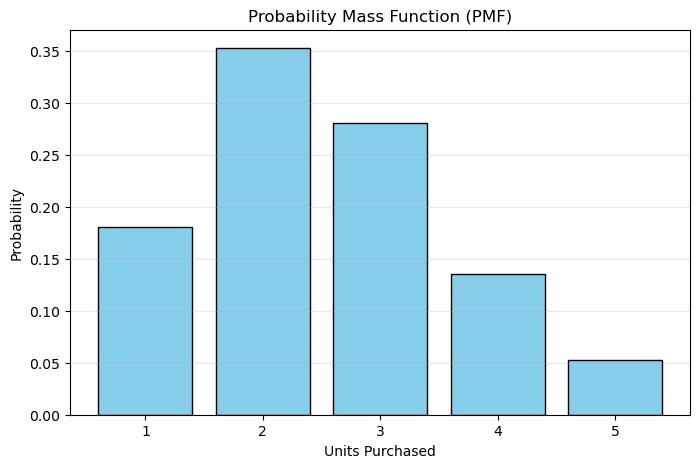

In [37]:
plt.figure(figsize=(8,5))

plt.bar(

    pmf.index,

    pmf.values,

    color="skyblue",

    edgecolor="black"

)

plt.title("Probability Mass Function (PMF)")

plt.xlabel("Units Purchased")

plt.ylabel("Probability")

plt.xticks(pmf.index)

plt.grid(axis="y",alpha=.3)

plt.show()

### Probability Density Function (PDF)

    A Probability Density Function (PDF) describes the probability distribution of a Continuous Random Variable.

    Unlike PMF, PDF does not assign probability to a single value.

    Instead, probability is calculated over an interval by measuring the area under the curve.

    Formula

$$
P(a\le X\le b)=\int_a^b f(x)\,dx
$$

    Where,
    - f(x) = Probability Density Function
    - a,b = Interval
    - Area under the curve = Probability

### Characteristics

    - Used only for continuous variables.
    - The probability at a single point is zero.
    - Probability is represented by the area under the curve.
    - Total area under the curve is always equal to 1.
    - PDF is represented by a smooth curve.

## Manual Example

    Suppose customer bill amounts are:

    ₹1500,₹2200,₹3600,₹4200,₹5100,₹6900

    Instead of calculating the probability of one exact bill amount,

    we calculate probabilities over ranges.

    Example: What is the probability that Customer Bill lies between ₹200 and ₹5000?

        This probability equals the area under the density curve between ₹2000 and ₹5000.

In [41]:
import numpy as np
from scipy.stats import gaussian_kde

# Continuous Variable
bill = Retail["Total_Bill"]

# Create PDF Model
pdf = gaussian_kde(bill)

# Generate x values
x = np.linspace(
    bill.min(),
    bill.max(),
    100
)

# Calculate PDF values
pdf_values = pdf(x)

# Display first few values
pdf_df = pd.DataFrame({
    "Total_Bill": x,
    "PDF": pdf_values
})

pdf_df.head()

,Total_Bill,PDF
0,501.000000,0.000038
1,647.131313,0.000041
2,793.262626,0.000045
3,939.393939,0.000048
4,1085.525253,0.000051


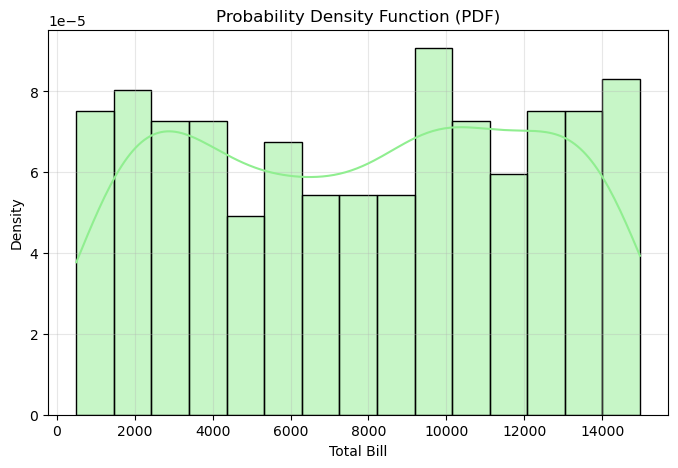

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    Retail["Total_Bill"],
    bins=15,
    stat="density",
    kde=True,
    color="lightgreen",
    edgecolor="black"
)

plt.title("Probability Density Function (PDF)")

plt.xlabel("Total Bill")

plt.ylabel("Density")

plt.grid(alpha=.3)

plt.show()

## Cumulative Distribution Function (CDF)

    A Cumulative Distribution Function (CDF) describes the cumulative probability that a random variable takes a value less than or equal to a given value.

    Unlike PMF and PDF, CDF always accumulates probabilities from the smallest value up to a specified value.

    The CDF tells us:
        What is the probability that the random variable is less than or equal to x?

    Formula
$$
F(x)=P(X\le x)
$$

    Where,

    - F(x) = Cumulative Distribution Function
    - X = Random Variable
    - x = Particular value

    The CDF always starts at 0 and gradually increases until it reaches 1.

    ## Characteristics of CDF
        - Used for both Discrete and Continuous Random Variables.
        - Values always lie between 0 and 1.
        - The CDF is always increasing.
        - The last cumulative probability is always 1.
        - CDF answers "less than or equal to" probability questions.

## Manual Example

Suppose customer bill amounts are:

| Customer | Bill (₹) |
|----------|----------|
|1|1000|
|2|2000|
|3|3000|
|4|4000|
|5|5000|

The cumulative probabilities are:

| Bill | CDF |
|------|-----|
|1000|0.20|
|2000|0.40|
|3000|0.60|
|4000|0.80|
|5000|1.00|

Interpretation:

There is a **60% probability** that a customer's bill is **₹3000 or less**.

In [44]:
Retail = Retail.sort_values("Total_Bill")

Retail["CDF"] = np.arange(
    1,
    len(Retail)+1
)/len(Retail)

Retail[["Total_Bill","CDF"]].head()

,Total_Bill,CDF
351,501,0.0025
222,538,0.0050
364,589,0.0075
369,605,0.0100
304,616,0.0125


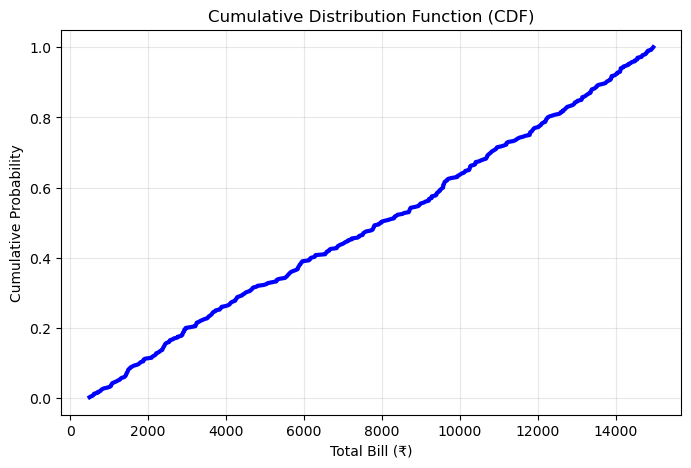

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    Retail["Total_Bill"],
    Retail["CDF"],
    linewidth=3,
    color="blue"
)

plt.title("Cumulative Distribution Function (CDF)")

plt.xlabel("Total Bill (₹)")

plt.ylabel("Cumulative Probability")

plt.grid(alpha=.3)

plt.show()